### Working with Pytoch Tensors

In [22]:
import torch
import numpy as np

### Working with PyTorch tensors

In [23]:
### Default datatype float32
x = torch.ones(2,2)
print(x)
print(x.dtype)

tensor([[1., 1.],
        [1., 1.]])
torch.float32


In [24]:
### Define specific datatype
x = torch.ones(2,2, dtype=torch.int8)
print(x)
print(x.dtype)

tensor([[1, 1],
        [1, 1]], dtype=torch.int8)
torch.int8


In [25]:
### Change datatype float64, it was int8
x = x.type(torch.float64)
print(x.dtype)

torch.float64


In [26]:
### Converting tensors into Numpy arrays
x = torch.rand(2,2)
print("Tensor x is :\n",x)
print(x.dtype)

######################################
print("#"*20)
######################################

y = x.numpy()
print("Array y is:\n",y)
print(y.dtype)

Tensor x is :
 tensor([[0.8681, 0.2131],
        [0.8720, 0.4876]])
torch.float32
####################
Array y is:
 [[0.86805123 0.21309966]
 [0.87195534 0.48760188]]
float32


In [27]:
### Convert Numpy arrays into tensors
x = np.zeros((2,2), dtype=np.float32)
print("Numpy array x is:\n",x)
print(x.dtype)

######################################
print("#"*20)
######################################

y = torch.from_numpy(x)
print("Tensor y is:\n",y)
print(y.dtype)

Numpy array x is:
 [[0. 0.]
 [0. 0.]]
float32
####################
Tensor y is:
 tensor([[0., 0.],
        [0., 0.]])
torch.float32


In [28]:
### Moving tensor between devices
# Define tensor on CPU

x = torch.tensor([1.5,2])
print("Tensor is:\n",x)
print("Tensor is on device: ",x.device)

######################################
print("#"*20)
######################################

# Define Device
if torch.cuda.is_available():
    device = torch.device('cuda:0')

# Move tensor onto the CUDA device
x = x.to(device)
print("Tensor is\n",x)
print(x.device)

######################################
print("#"*20)
######################################

# Move tensor onto the CPU
device = torch.device("cpu")
x=x.to(device=device)
print("Tensor is\n",x)
print("Device is ",x.device)

######################################
print("#"*20)
######################################

# Create tensor directly on any device:
device=torch.device("cuda:0")
x=torch.ones((2,3), device=device)
print("Tensor is\n",x)
print("Tensor shape is ",x.shape)
print("Device is ",x.device)


Tensor is:
 tensor([1.5000, 2.0000])
Tensor is on device:  cpu
####################
Tensor is
 tensor([1.5000, 2.0000], device='cuda:0')
cuda:0
####################
Tensor is
 tensor([1.5000, 2.0000])
Device is  cpu
####################
Tensor is
 tensor([[1., 1., 1.],
        [1., 1., 1.]], device='cuda:0')
Tensor shape is  torch.Size([2, 3])
Device is  cuda:0


### Loading and Processing Data

In [29]:
# 1. First Load MNIST training dataset

from torchvision import datasets
path2data = "./data"
train_data = datasets.MNIST(path2data, train=True, download=True)

In [30]:
# 2. Extract the input data and target labels
x_train, y_train = train_data.data, train_data.targets
print("X-train shape: ",x_train.shape)
print("Y-train shape: ",y_train.shape)

X-train shape:  torch.Size([60000, 28, 28])
Y-train shape:  torch.Size([60000])


In [31]:
# 3. Load MNIST test dataset:
val_data = datasets.MNIST(path2data, train=False, download=True)

In [32]:
# 4. Extract data and targets
x_val, y_val = val_data.data, val_data.targets
print("X-validation shape: ",x_val.shape)
print("Y-validation shape: ", y_val.shape)

X-validation shape:  torch.Size([10000, 28, 28])
Y-validation shape:  torch.Size([10000])


In [33]:
# 5. Add new dimension to the tensors
## Pytorch requires B*C*H*W 
### Batch size(Number of images) = 60000
### Number of channels(Color Space) = 1
### Image Height = 28
### Image Width = 28

if len(x_train.shape) == 3:
    x_train = x_train.unsqueeze(1)
print("X-train shape \n",x_train.shape)

if len(x_val.shape) == 3:
    x_val = x_val.unsqueeze(1)
print("X-validation shape \n",x_val.shape)

X-train shape 
 torch.Size([60000, 1, 28, 28])
X-validation shape 
 torch.Size([10000, 1, 28, 28])


In [34]:
# 6. Import some packages
from torchvision import utils
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [35]:
# 7. Define helper functions to display tensors as image:
def show(img):
    # Convert tensor to numpy array
    plt.clf()
    npimage=img.numpy()

    # Convert numpy array to H*W*C shape
    npimg_trans = np.transpose(npimage,(1,2,0))
    plt.imshow(npimg_trans, interpolation="nearest")
    plt.show()

torch.Size([3, 152, 242])


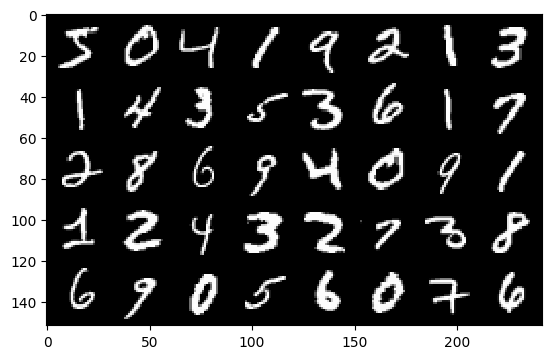

In [36]:
# 8. Create grid images and display them
# make grid of 40 images, 8 images per row
x_grid = utils.make_grid(x_train[:40], nrow=8, padding=2)
print(x_grid.shape)

show(x_grid)

### Data Transformations (Augmentation)

#### Data Transformation

In [37]:
# 1. Define transform class to apply some image transformation
from torchvision import transforms

path2data = "./data"

#Loading MNIST training dataset
train_data = datasets.MNIST(path2data, train=True, download=True)

#Define transformation
data_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.RandomVerticalFlip(p=1),
    transforms.ToTensor(),
])

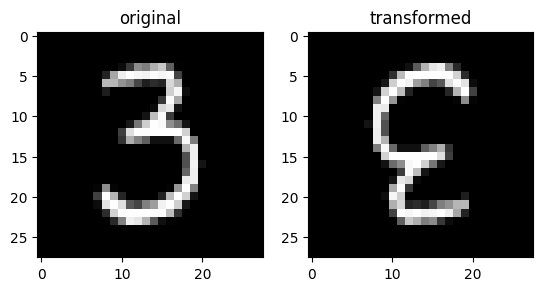

In [38]:
# 2. Apply transformation on an image from MNIST

# Get sample image
img = train_data[50][0]

# Transform image
img_trans = data_transform(img)

# Conver tensor to numpy array
img_trans_np = img_trans.numpy()

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray")
plt.title("original")
plt.subplot(1,2,2)
plt.imshow(img_trans_np[0],cmap="gray");
plt.title("transformed")
plt.show()


In [39]:
# 3. Pass the transformet function to the dataset class:
data_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.RandomVerticalFlip(p=1),
    transforms.ToTensor(),
])

# Loading MNIST training data with on-the-fly transformations
train_data = datasets.MNIST(path2data, train=True, download=True, transform=data_transform)

#### Wrapping tensors into Dataset and DataLoader

In [40]:
from torch.utils.data import TensorDataset

## wrap tensors into a dataset
train_ds = TensorDataset(x_train, y_train)
val_ds = TensorDataset(x_val, y_val)

for x,y in train_ds:
    print(x.shape,y.item())
    break

torch.Size([1, 28, 28]) 5


In [41]:
from torch.utils.data import DataLoader

# create a data loader from dataset
train_dl = DataLoader(train_ds, batch_size=8)
val_dl = DataLoader(val_ds, batch_size=8)

# iterate over batches
for xb,yb in train_dl:
    print(xb.shape)
    print(yb.shape)
    break
    # your training code will be here!

torch.Size([8, 1, 28, 28])
torch.Size([8])


#### Creating Data Loaders

In [42]:
# 1. Create 2 data loaders for traing and validation
from torch.utils.data import DataLoader

# Create a data loader from dataset
train_dl = DataLoader(train_ds, batch_size=8)
val_dl = DataLoader(val_ds,batch_size=8)

# Iterate over batches
for xb, yb in train_dl:
    print(xb.shape)
    print(yb.shape)
    break


torch.Size([8, 1, 28, 28])
torch.Size([8])


### Building Models

#### Defining a Linear Layer

In [43]:
from torch import nn 

# Input Tensor Dimension 64*1000
input_tensor = torch.randn(64,1000)

# Linear Layer with 1000 inputs and 100 outputs
linear_layer = nn.Linear(1000,10)

# Output of Linear Layer
output = linear_layer(input_tensor)

print(output.shape)

torch.Size([64, 10])


In [44]:
model = nn.Sequential(
    nn.Linear(4,5),
    nn.ReLU(),
    nn.Linear(5,1),
)
print(model)

Sequential(
  (0): Linear(in_features=4, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=1, bias=True)
)


### Defining Models Using nn.Module


In [45]:
import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, 5, 1)
        self.conv2 = nn.Conv2d(8, 16, 5, 1)
        self.fc1 = nn.Linear(4*4*16, 100)
        self.fc2 = nn.Linear(100, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)
        x = x.view(-1, 4*4*16)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = Net()
print(model)

Net(
  (conv1): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)


#### Move Model to GPU

In [46]:
print(next(model.parameters()).device)

cpu


In [47]:
device = torch.device("cuda:0")
model.to(device=device)

print(next(model.parameters()).device)

cuda:0


#### Printing Model Summary

In [48]:
from torchsummary import summary
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 24, 24]             208
            Conv2d-2             [-1, 16, 8, 8]           3,216
            Linear-3                  [-1, 100]          25,700
            Linear-4                   [-1, 10]           1,010
Total params: 30,134
Trainable params: 30,134
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.11
Estimated Total Size (MB): 0.16
----------------------------------------------------------------


### Defining Loss and Optimizer

#### Defining Loss Function

In [49]:
from torch import nn

loss_func = nn.NLLLoss(reduction="sum")

for xb, yb in train_dl:
    # move batch to cuda device
    xb = xb.type(torch.float).to(device)
    yb = yb.to(device)

    #get output of model(prediction)
    out = model(xb)
    
    #Calculate loss value
    loss = loss_func(out,yb)
    print(loss.item())
    break

loss.backward()

63.75249099731445


#### Defining Optimizer

In [50]:
from torch import optim

opt = optim.Adam(model.parameters(), lr=1e-4)

# update model parameters
opt.step()

# set gradients to zero
opt.zero_grad()

#### Training and Evaluation Model

In [51]:
import numpy as np

def metrics_batch(target, output):
    # obtain output class
    pred = output.argmax(dim=1, keepdim=True)
    
    # compare output class with target class
    corrects=pred.eq(target.view_as(pred)).sum().item()
    return corrects

def loss_batch(loss_func, xb, yb,yb_h, opt=None):
    
    # obtain loss
    loss = loss_func(yb_h, yb)
    
    # obtain performance metric
    metric_b = metrics_batch(yb,yb_h)
    
    if opt is not None:
        loss.backward()
        opt.step()
        opt.zero_grad()

    return loss.item(), metric_b


def loss_epoch(model,loss_func,dataset_dl,opt=None):
    loss=0.0
    metric=0.0
    len_data=len(dataset_dl.dataset)
    for xb, yb in dataset_dl:
        xb=xb.type(torch.float).to(device)
        yb=yb.to(device)
        
        # obtain model output
        yb_h=model(xb)

        loss_b,metric_b=loss_batch(loss_func, xb, yb,yb_h, opt)
        loss+=loss_b
        if metric_b is not None:
            metric+=metric_b
    loss/=len_data
    metric/=len_data
    return loss, metric



def train_val(epochs, model, loss_func, opt, train_dl, val_dl):
    for epoch in range(epochs):
        model.train()
        train_loss, train_metric=loss_epoch(model,loss_func,train_dl,opt)
        
            
        model.eval()
        with torch.no_grad():
            val_loss, val_metric=loss_epoch(model,loss_func,val_dl)
        
        accuracy=100*val_metric

        print("epoch: %d, train loss: %.6f, val loss: %.6f, accuracy: %.2f" %(epoch, train_loss,val_loss,accuracy))

In [52]:
for xb, yb in train_dl:
    print(xb.shape)
    break

torch.Size([8, 1, 28, 28])


In [53]:
num_epochs = 5

train_val(num_epochs, model, loss_func, opt, train_dl, val_dl)
# train_val(epochs=num_epochs,model=model, loss_func=loss_func, opt=opt,train_dl=train_dl,val_dl=val_dl)

epoch: 0, train loss: 0.237906, val loss: 0.107463, accuracy: 96.44
epoch: 1, train loss: 0.073645, val loss: 0.072169, accuracy: 97.61
epoch: 2, train loss: 0.047031, val loss: 0.062706, accuracy: 97.97
epoch: 3, train loss: 0.033203, val loss: 0.048368, accuracy: 98.48
epoch: 4, train loss: 0.025629, val loss: 0.051398, accuracy: 98.52


#### Storing and Loading Model